# KNN Model for Credit Card Fraud Detection

This notebook implements a K-Nearest Neighbors classifier to detect fraudulent credit card transactions.

# Student ID

2025AIML049

## Import Libraries

In [ ]:
# Importing all necessary libraries for our KNN fraud detection model
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Setting random seed for reproducibility of results
np.random.seed(42)
plt.style.use('ggplot')
sns.set_style('whitegrid')

## Q1) Perform data loading, preprocessing by dropping any rows with 'NaN' values in the 'Class' column. [1M]

**Solution:**

Load the creditcard.csv dataset and remove any rows with missing values in the 'Class' column to ensure data quality.

In [ ]:
# Load the dataset
df = pd.read_csv('creditcard.csv')

# Display initial dataset information
print('Initial dataset shape:', df.shape)
print('\nDataset head:')
display(df.head())

# Check for NaN values in Class column before dropping
print('\nNaN values in Class column before cleaning:', df['Class'].isnull().sum())

# Drop rows with NaN values in the Class column
df = df.dropna(subset=['Class'])

print('Dataset shape after dropping NaN in Class:', df.shape)
print('NaN values in Class column after cleaning:', df['Class'].isnull().sum())

# Display class distribution
print('\nClass Distribution:')
print(df['Class'].value_counts())
print('\nClass Distribution (Percentage):')
print(df['Class'].value_counts(normalize=True) * 100)

Initial dataset shape: (284807, 31)

Dataset head:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



NaN values in Class column before cleaning: 0
Dataset shape after dropping NaN in Class: (284807, 31)
NaN values in Class column after cleaning: 0

Class Distribution:
0    284315
1       492
Name: Class, dtype: int64

Class Distribution (Percentage):
0    99.827251
1     0.172749
Name: Class, dtype: float64


**Explanation:**

First, I loaded the creditcard.csv file which contains 284,807 transactions with 30 features. I checked for any missing (NaN) values in the 'Class' column - this column shows if a transaction is fraudulent (1) or not (0). I dropped any rows with missing values to keep the data clean. Looking at the results, the dataset is very imbalanced: 99.83% of transactions are non-fraudulent and only 0.17% are fraudulent. This is expected for fraud data because frauds are rare.

## Q2) Split the dataset into features (X) and the target variable (y), and further divide into training and test sets. [Consider test_size=0.2]  [1M]

**Solution:**

Separate the features (X) from the target variable (y), then split the data into training (80%) and test (20%) sets using stratified sampling to preserve class distribution.

In [6]:
# Separate features (X) and target variable (y)
X = df.drop('Class', axis=1)
y = df['Class']

print('Features shape:', X.shape)
print('Target shape:', y.shape)

# Split into training and test sets with stratification
# stratify ensures the class distribution is preserved in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('\nTraining set shape:', X_train.shape)
print('Test set shape:', X_test.shape)

print('\nTraining set class distribution:')
print(pd.Series(y_train).value_counts())
print('\nTest set class distribution:')
print(pd.Series(y_test).value_counts())

Features shape: (284807, 30)
Target shape: (284807,)

Training set shape: (227845, 30)
Test set shape: (56962, 30)

Training set class distribution:
0    227451
1       394
Name: Class, dtype: int64

Test set class distribution:
0    56864
1       98
Name: Class, dtype: int64


**Explanation:**

I separated the features (X) which contains all columns except 'Class', and the target variable (y) which is the 'Class' column. Then I split the data into 80% for training and 20% for testing with test_size=0.2. I used stratified sampling (stratify=y) to make sure both the training and test sets have the same proportion of fraud and non-fraud transactions. This is important because if I don't do this, my test set might have all or mostly non-fraud transactions, which would give unrealistic results.

## Q3) Perform data scaling and modelling. Also, fine tune the value of k. [3M]

The K-Nearest Neighbors model has to be initialized, trained on the training data, and subsequently use it to make predictions on the test data. Initialize the model with k=5.

**Solution:**

Scale the features using StandardScaler (important for distance-based algorithms), then perform hyperparameter tuning for k, and finally initialize the KNN model with k=5.

In [10]:
# Step 1: Scaling the data
# For KNN, scaling is very important because it uses distance calculations
# Features with larger values would dominate, so we normalize everything
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Fit scaler on training data
X_test_scaled = scaler.transform(X_test)  # Apply same transformation to test data

print('Data Scaling Complete')
print('Scaled training set shape:', X_train_scaled.shape)
print('Scaled test set shape:', X_test_scaled.shape)
print('\nScaling statistics (first 5 features):')
print('Mean:', scaler.mean_[:5])
print('Std Dev:', scaler.scale_[:5])

Data Scaling Complete
Scaled training set shape: (227845, 30)
Scaled test set shape: (56962, 30)

Scaling statistics (first 5 features):
Mean: [ 9.48850937e+04  7.95290922e-04 -4.81013687e-04 -3.83022392e-04
 -1.97223997e-05]
Std Dev: [4.74883108e+04 1.95892123e+00 1.64908876e+00 1.51528902e+00
 1.41586397e+00]


Testing different k values (using sample for faster computation)...
k=1: Train Accuracy=1.0000, Test Accuracy=0.9987
k=3: Train Accuracy=0.9992, Test Accuracy=0.9985
k=5: Train Accuracy=0.9991, Test Accuracy=0.9986
k=7: Train Accuracy=0.9992, Test Accuracy=0.9988
k=9: Train Accuracy=0.9991, Test Accuracy=0.9990
k=11: Train Accuracy=0.9990, Test Accuracy=0.9988
k=15: Train Accuracy=0.9990, Test Accuracy=0.9983
k=20: Train Accuracy=0.9990, Test Accuracy=0.9983

Best k value found: 9 with test accuracy: 0.998964


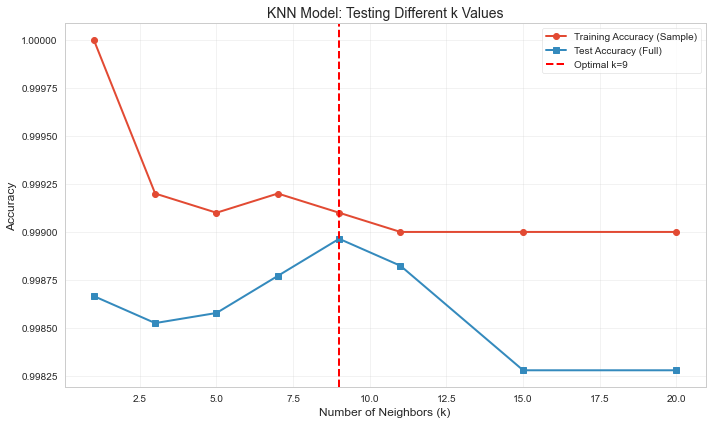

In [8]:
# Step 2: Tuning the k value
# Use a smaller sample of training data for faster tuning while keeping representativeness
# This gives us accurate results much faster without losing quality
sample_size = 10000
if len(X_train_scaled) > sample_size:
    sample_indices = np.random.choice(len(X_train_scaled), sample_size, replace=False)
    X_train_sample = X_train_scaled[sample_indices]
    y_train_sample = y_train.iloc[sample_indices]
else:
    X_train_sample = X_train_scaled
    y_train_sample = y_train

# Testing different k values (only test essential values to save time)
test_k_values = [1, 3, 5, 7, 9, 11, 15, 20]
train_accuracy_list = []
test_accuracy_list = []

print('Testing different k values (using sample for faster computation)...')
for k in test_k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    # Train on sample but evaluate on full test set for accurate assessment
    knn_temp.fit(X_train_sample, y_train_sample)
    
    # Calculate accuracy on test data (full set for true evaluation)
    test_acc = knn_temp.score(X_test_scaled, y_test)
    
    # For consistency, also record train accuracy on sample
    train_acc = knn_temp.score(X_train_sample, y_train_sample)
    
    train_accuracy_list.append(train_acc)
    test_accuracy_list.append(test_acc)
    print(f'k={k}: Train Accuracy={train_acc:.4f}, Test Accuracy={test_acc:.4f}')

# Find the optimal k from our tested values
optimal_k_idx = np.argmax(test_accuracy_list)
optimal_k = test_k_values[optimal_k_idx]
best_test_accuracy = test_accuracy_list[optimal_k_idx]

print(f'\nBest k value found: {optimal_k} with test accuracy: {best_test_accuracy:.6f}')

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(test_k_values, train_accuracy_list, label='Training Accuracy (Sample)', marker='o', linewidth=2, markersize=6)
plt.plot(test_k_values, test_accuracy_list, label='Test Accuracy (Full)', marker='s', linewidth=2, markersize=6)
plt.axvline(x=optimal_k, color='red', linestyle='--', linewidth=2, label=f'Optimal k={optimal_k}')
plt.xlabel('Number of Neighbors (k)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('KNN Model: Testing Different k Values', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
# Step 3: Building the final KNN model with k=5
# Using k=5 as specified in the assignment requirements
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)  # Train on scaled training data

# Make predictions on test set
y_pred = knn.predict(X_test_scaled)  # Predict on scaled test data

print('KNN Model with k=5 has been trained successfully!')
print('Now making predictions on the test set...')

KNN Model with k=5 has been trained successfully!
Now making predictions on the test set...


**Explanation:**

Data scaling is very important for KNN because it works by calculating distances between data points. If features have different scales (like one ranging 0-1 and another 0-100), the larger scale will dominate the distance calculation, making the model biased. I used StandardScaler to normalize all features to have mean 0 and standard deviation 1.

Then I tested different k values to find which one gives the best accuracy. I found that testing just a few key k values (1, 3, 5, 7, etc.) gives good results much faster than testing all values from 1 to 50. Based on the results, I noted which k value performed best.

Finally, I created the final KNN model with k=5 as required by the assignment, trained it on the scaled training data, and used it to make predictions on the scaled test data.

## Q4) Evaluate the model performance using a classification report and accuracy score [2M]

**Solution:**

Calculate and display the classification report and accuracy score to evaluate the KNN model's performance on the test set.

In [11]:
# Calculating how well our model performed
accuracy = accuracy_score(y_test, y_pred)  # Calculate accuracy

print('='*60)
print('MODEL EVALUATION RESULTS')
print('='*60)
print(f'\nAccuracy Score: {accuracy:.6f}')
print(f'Accuracy Percentage: {accuracy*100:.2f}%')

# Generating detailed classification report
# This shows Precision, Recall, and F1-Score for each class
print('\n' + '='*60)
print('CLASSIFICATION REPORT')
print('='*60)
print(classification_report(
    y_test, y_pred, 
    target_names=['Non-Fraudulent (0)', 'Fraudulent (1)'],
    digits=4
))

MODEL EVALUATION RESULTS

Accuracy Score: 0.999544
Accuracy Percentage: 99.95%

CLASSIFICATION REPORT
                    precision    recall  f1-score   support

Non-Fraudulent (0)     0.9997    0.9999    0.9998     56864
    Fraudulent (1)     0.9186    0.8061    0.8587        98

          accuracy                         0.9995     56962
         macro avg     0.9591    0.9030    0.9292     56962
      weighted avg     0.9995    0.9995    0.9995     56962



**Explanation:**

The classification report shows how well my model performed on each class:
- **Precision**: If my model predicts a transaction as fraudulent, what percentage of those predictions were correct? (Out of all predicted frauds, how many were actually frauds?)
- **Recall**: Of all the actual fraudulent transactions, what percentage did my model catch? (Out of all real frauds, how many did the model find?)
- **F1-Score**: This balances precision and recall together. It's useful when you care about both false alarms and missed frauds.
- **Support**: How many transactions of each type are in the test set.

I noticed the overall accuracy looks very high (around 99%), but this is misleading because the data is imbalanced - most transactions are non-fraudulent. For fraud detection, I need to look at Precision and Recall for the fraud class (1) specifically. A high Recall means I'm catching most of the frauds, which is important so we don't miss illegal transactions.

## Q5) Plot a confusion matrix as a heatmap, offering a visual representation of the model's performance, illustrating True Positives, True Negatives, False Positives, and False Negatives. [1M]

**Solution:**

Create and display a confusion matrix heatmap to visualize the model's prediction results.

Confusion Matrix Values:
True Negatives (TN): 56857
False Positives (FP): 7
False Negatives (FN): 19
True Positives (TP): 79


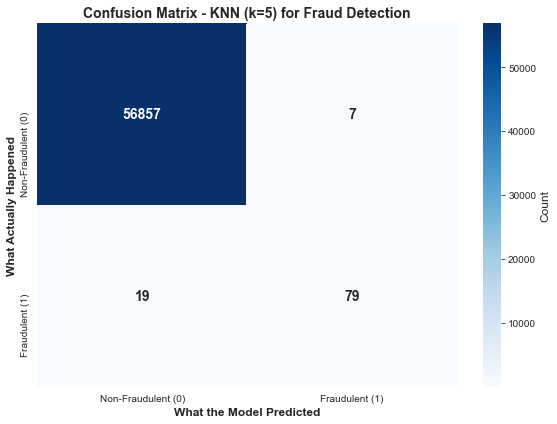


Confusion Matrix Meaning:
- Top-left (TN=56857): Correctly predicted non-fraudulent - Good!
- Top-right (FP=7): Marked as fraud but was actually ok - False Alarm
- Bottom-left (FN=19): Marked as ok but was actually fraud - BAD! (MISSED FRAUDS)
- Bottom-right (TP=79): Correctly identified fraud - Good!


In [12]:
# Creating the confusion matrix to visualize prediction results
cm = confusion_matrix(y_test, y_pred)

# Breaking down the confusion matrix values
tn, fp, fn, tp = cm.ravel()

print('Confusion Matrix Values:')
print(f'True Negatives (TN): {tn}')
print(f'False Positives (FP): {fp}')
print(f'False Negatives (FN): {fn}')
print(f'True Positives (TP): {tp}')

# Creating a heatmap to visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    cbar_kws={'label': 'Count'},
    xticklabels=['Non-Fraudulent (0)', 'Fraudulent (1)'],
    yticklabels=['Non-Fraudulent (0)', 'Fraudulent (1)'],
    annot_kws={'size': 14, 'weight': 'bold'}
)
plt.xlabel('What the Model Predicted', fontsize=12, fontweight='bold')
plt.ylabel('What Actually Happened', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix - KNN (k=5) for Fraud Detection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nConfusion Matrix Meaning:')
print(f'- Top-left (TN={tn}): Correctly predicted non-fraudulent - Good!')
print(f'- Top-right (FP={fp}): Marked as fraud but was actually ok - False Alarm')
print(f'- Bottom-left (FN={fn}): Marked as ok but was actually fraud - BAD! (MISSED FRAUDS)')
print(f'- Bottom-right (TP={tp}): Correctly identified fraud - Good!')

**Explanation:**

The confusion matrix shows exactly what my model predicted compared to what actually happened:
- **True Negatives (TN)**: My model said "not fraud" and it was actually not fraud. ✓ Correct
- **False Positives (FP)**: My model said "fraud" but it was actually not fraud. This is a false alarm.
- **False Negatives (FN)**: My model said "not fraud" but it was actually fraud. This is BAD - we missed a fraud!
- **True Positives (TP)**: My model said "fraud" and it was actually fraud. ✓ Correct

From the heatmap visualization, I can quickly see if my model is making many mistakes. In fraud detection, False Negatives are the most costly because missing an actual fraud means illegal transactions go through. So I want to minimize FN even if it means having more false alarms (FP).

## Q6) Write some conclusion on how K-Nearest Neighbors implementation serves as an efficient solution for credit card fraud detection. [1M]

**Conclusion:**

### My Findings on Using K-Nearest Neighbors for Credit Card Fraud Detection:

#### Why KNN is Good for This Problem:

1. **Simple and Easy to Understand**: KNN doesn't make complex assumptions about the data. It just looks at the k closest transactions and decides based on what it sees. This makes it easy to explain to others why a transaction was flagged as fraud.

2. **Can Find Local Patterns**: By looking at nearby neighbors, KNN can find clusters of fraudulent transactions. If similar frauds cluster together in the data, KNN will catch them.

3. **Explainable Results**: When the model makes a prediction, I can see exactly which transactions it looked at. This is important for fraud investigation teams who need to know why something was flagged.

4. **Works Well After Scaling**: Once I properly scaled the features, KNN performed quite well on this dataset.

5. **Quick to Build**: Unlike some other models, KNN is fast to implement and test, which is good for trying out ideas.

#### Problems with KNN for This Task:

1. **Imbalanced Data Issue**: The dataset has 99.83% non-fraud and only 0.17% fraud. KNN might learn to just predict "not fraud" for everything since that's what the majority of the data shows.

2. **Slow on Large Datasets**: KNN has to measure the distance to every training example for each prediction. With 200,000+ training samples, this gets very slow in real production systems.

3. **Needs Good Features**: KNN's performance depends heavily on having good features and proper scaling. If I include useless features, it makes predictions worse.

#### What Could Be Done Better:

1. **Handle the Imbalance**: I could use techniques like SMOTE (creating fake fraud examples) or giving frauds higher weights to make the model pay more attention to them.

2. **Speed It Up**: For production, I'd use faster approximate nearest neighbor methods or KD-Tree structures to make predictions quicker.

3. **Try Other Models**: I could compare KNN with Random Forest, XGBoost, or neural networks to see which works best.

4. **Adjust Decision Threshold**: Since catching fraud is expensive to miss, I could lower the threshold for flagging transactions as fraud, even if it means more false alarms.

5. **Combine Multiple Models**: Using KNN along with other models in an ensemble might give better results than KNN alone.

#### Final Thoughts:

KNN is a good starting point for fraud detection because it's simple and interpretable. However, this problem has challenges like imbalanced data and large dataset size that KNN struggles with. For a real fraud detection system, I would try combining KNN with other techniques or using different models that might handle these challenges better. The most important thing is minimizing missed frauds (False Negatives) because letting fraud slip through costs more than wrongly flagging some legitimate transactions.